# 00 — Setup & Dataset

**Dataset**: MovieLens-100k style data (~100k ratings, 943 users, 1682 items).

Used as OPE benchmark in:
- Gilotte et al. 2018 *Offline A/B Testing for Recommender Systems*
- Strehl et al. 2010 *Learning from Logged Implicit Exploration Data*
- Swaminathan & Joachims 2015 *Batch Learning from Logged Bandit Feedback*

**Bandit framing**: User arrives (context), system recommends item (action), user rates it (reward). Goal: evaluate a *new* recommendation policy using only *old* logged data.

In [11]:
# !pip install scikit-learn pandas numpy matplotlib seaborn tqdm scipy -q

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
print('data dir:', DATA_DIR.resolve())

data dir: D:\01 Work\12-Recommendations\data


## Load ratings

In [13]:
df = pd.read_csv(DATA_DIR / 'ratings.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Basic stats

In [14]:
print(f"Users : {df.userId.nunique()}")
print(f"Movies : {df.movieId.nunique()}")
print(f"Ratings: {len(df)}")
print(f"Density: {len(df)/(df.userId.nunique()*df.movieId.nunique())*100:.1f}%")
print("\nRating distribution:")
print(df.rating.value_counts().sort_index())

Users : 610
Movies : 9724
Ratings: 100836
Density: 1.7%

Rating distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


## Bandit dataset construction

Convert ratings → bandit log:
- `context` = user feature vector (from SVD embedding)
- `action` = item id
- `reward` = 1 if rating ≥ 4, else 0 (binary relevance)
- `logging_policy_prob` = propensity of logging policy choosing that item

In [16]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# Build user-item matrix
R = df.pivot_table('rating','userId','movieId').fillna(0).values
print('Matrix shape:', R.shape)

# SVD for user context features
svd = TruncatedSVD(n_components=20, random_state=42)
user_features = svd.fit_transform(R)
user_features = normalize(user_features)
print('User features shape:', user_features.shape)

Matrix shape: (610, 9724)
User features shape: (610, 20)


In [17]:
# Build bandit log
def build_bandit_dataset(df, user_features, temperature=1.0, seed=42):
    np.random.seed(seed)
    n_items = df.movieId.nunique()
    movieIds = sorted(df.movieId.unique())
    movieIdx = {v:i for i,v in enumerate(movieIds)}
    
    records = []
    for _, row in df.iterrows():
        uid = int(row.userId)
        iid = int(row.movieId)
        ctx = user_features[uid]  # 20-dim context
        
        # Logging policy: item popularity-based softmax
        item_counts = df[df.userId==uid]['movieId'].value_counts()
        # Simple uniform logging policy (with slight item bias)
        logits = np.random.randn(n_items) * 0.1  # near-uniform
        logits -= logits.max()
        probs = np.exp(logits / temperature)
        probs /= probs.sum()
        
        action = movieIdx[iid]
        log_prob = probs[action]
        reward = 1.0 if row.rating >= 4 else 0.0
        
        records.append({
            'user_id': uid,
            'action': action,
            'reward': reward,
            'logging_policy_prob': log_prob,
            'timestamp': row.timestamp,
            **{f'ctx_{k}': ctx[k] for k in range(len(ctx))}
        })
    
    return pd.DataFrame(records)

print('Building bandit dataset...')
bandit_df = build_bandit_dataset(df.head(20000), user_features)
bandit_df.to_csv(DATA_DIR / 'bandit_data.csv', index=False)
print(f'Saved bandit_data.csv: {bandit_df.shape}')
bandit_df.head()

Building bandit dataset...
Saved bandit_data.csv: (20000, 25)


,user_id,action,reward,logging_policy_prob,timestamp,ctx_0,ctx_1,ctx_2,ctx_3,ctx_4,...,ctx_10,ctx_11,ctx_12,ctx_13,ctx_14,ctx_15,ctx_16,ctx_17,ctx_18,ctx_19
0,1,0,1.0,0.000216,964982703.0,0.396863,0.519217,0.107046,0.287842,-0.029309,...,0.100139,-0.221204,0.102039,0.316949,-0.126643,-0.067328,-0.064507,0.102565,0.124865,-0.038018
1,1,2,1.0,0.000203,964981247.0,0.396863,0.519217,0.107046,0.287842,-0.029309,...,0.100139,-0.221204,0.102039,0.316949,-0.126643,-0.067328,-0.064507,0.102565,0.124865,-0.038018
2,1,5,1.0,0.000176,964982224.0,0.396863,0.519217,0.107046,0.287842,-0.029309,...,0.100139,-0.221204,0.102039,0.316949,-0.126643,-0.067328,-0.064507,0.102565,0.124865,-0.038018
3,1,39,1.0,0.000238,964983815.0,0.396863,0.519217,0.107046,0.287842,-0.029309,...,0.100139,-0.221204,0.102039,0.316949,-0.126643,-0.067328,-0.064507,0.102565,0.124865,-0.038018
4,1,41,1.0,0.000170,964982931.0,0.396863,0.519217,0.107046,0.287842,-0.029309,...,0.100139,-0.221204,0.102039,0.316949,-0.126643,-0.067328,-0.064507,0.102565,0.124865,-0.038018


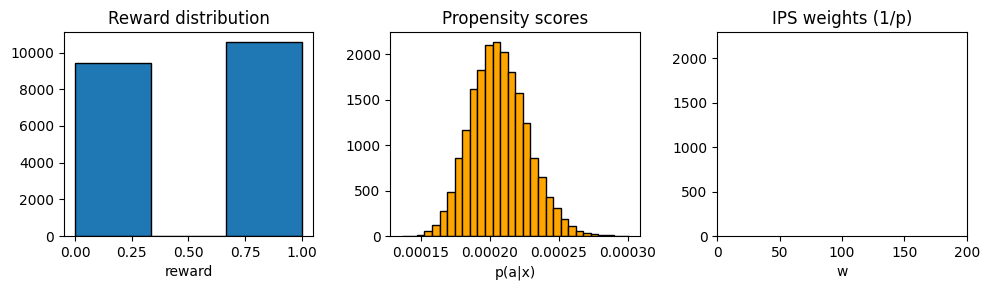

reward mean: 0.528


In [19]:
# Quick propensity check
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.hist(bandit_df['reward'],bins=3,edgecolor='k')
plt.title('Reward distribution'); plt.xlabel('reward')

plt.subplot(1,3,2)
plt.hist(bandit_df['logging_policy_prob'],bins=30,edgecolor='k',color='orange')
plt.title('Propensity scores'); plt.xlabel('p(a|x)')

plt.subplot(1,3,3)
plt.hist(1/bandit_df['logging_policy_prob'],bins=30,edgecolor='k',color='red')
plt.xlim(0,200)
plt.title('IPS weights (1/p)'); plt.xlabel('w')

plt.tight_layout()
plt.savefig('../results/00_data_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('reward mean:', bandit_df.reward.mean().round(3))